In [1]:
pip install astropy xgboost

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import astropy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore') # just hiding some annoying warnings for cleaner output

In [36]:
df = pd.read_csv('/content/drive/MyDrive/star_classification/star_classification.csv')

In [37]:
print('df shape:', df.shape)

print('\ndf head:')
display(df.head())

print('\ndf dtypes:')
print(df.dtypes)

print('\nclass value counts:')
print(df['class'].value_counts())

df shape: (100000, 18)

df head:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



df dtypes:
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class           object
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object

class value counts:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


## Data Cleaning

In [38]:
print('Nulls before cleaning:')
print(df.isnull().sum())

columns_to_drop = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'fiber_ID', 'MJD', 'plate']
df = df.drop(columns=columns_to_drop)
print(f"\nDropped columns: {columns_to_drop}")

initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicate_rows = initial_rows - df.shape[0]
print(f"\nRemoved {duplicate_rows} duplicate rows.")

print('\nFinal df shape after cleaning:', df.shape)

Nulls before cleaning:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Dropped columns: ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'fiber_ID', 'MJD', 'plate']

Removed 0 duplicate rows.

Final df shape after cleaning: (100000, 9)


## Class Balance

I checked the distribution of our target variable. It looks pretty imbalanced, with 'GALAXY' making up almost 60% of the data. This might make the model a bit biased, so I'll keep an eye on that.

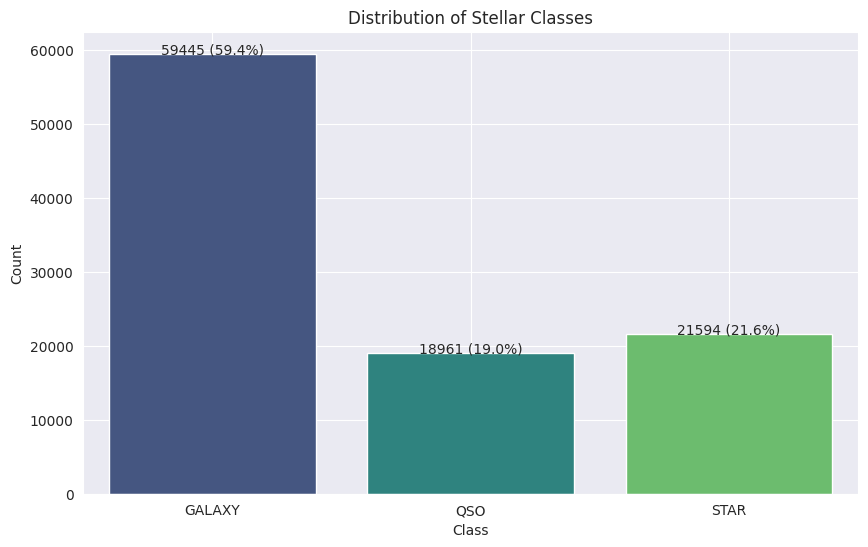


Class percentage breakdown:
class
GALAXY    59.445
STAR      21.594
QSO       18.961
Name: proportion, dtype: float64


In [39]:
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
ax = sns.countplot(x='class', data=df, palette='viridis', hue='class', legend=False)
plt.title('Distribution of Stellar Classes')
plt.xlabel('Class')
plt.ylabel('Count')

total = float(len(df))
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 3,
            '{:1.0f} ({:1.1f}%)'.format(height, (height/total)*100),
            ha="center", fontsize=10)
plt.grid(True)
plt.savefig('eda_plot_1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClass percentage breakdown:')
print(df['class'].value_counts(normalize=True) * 100)

## Feature Correlation

I looked at how our numerical features correlate. Some of them are super correlated, like `u`, `g`, `z`, `r`, and `i`. That might affect some models, but we'll see.

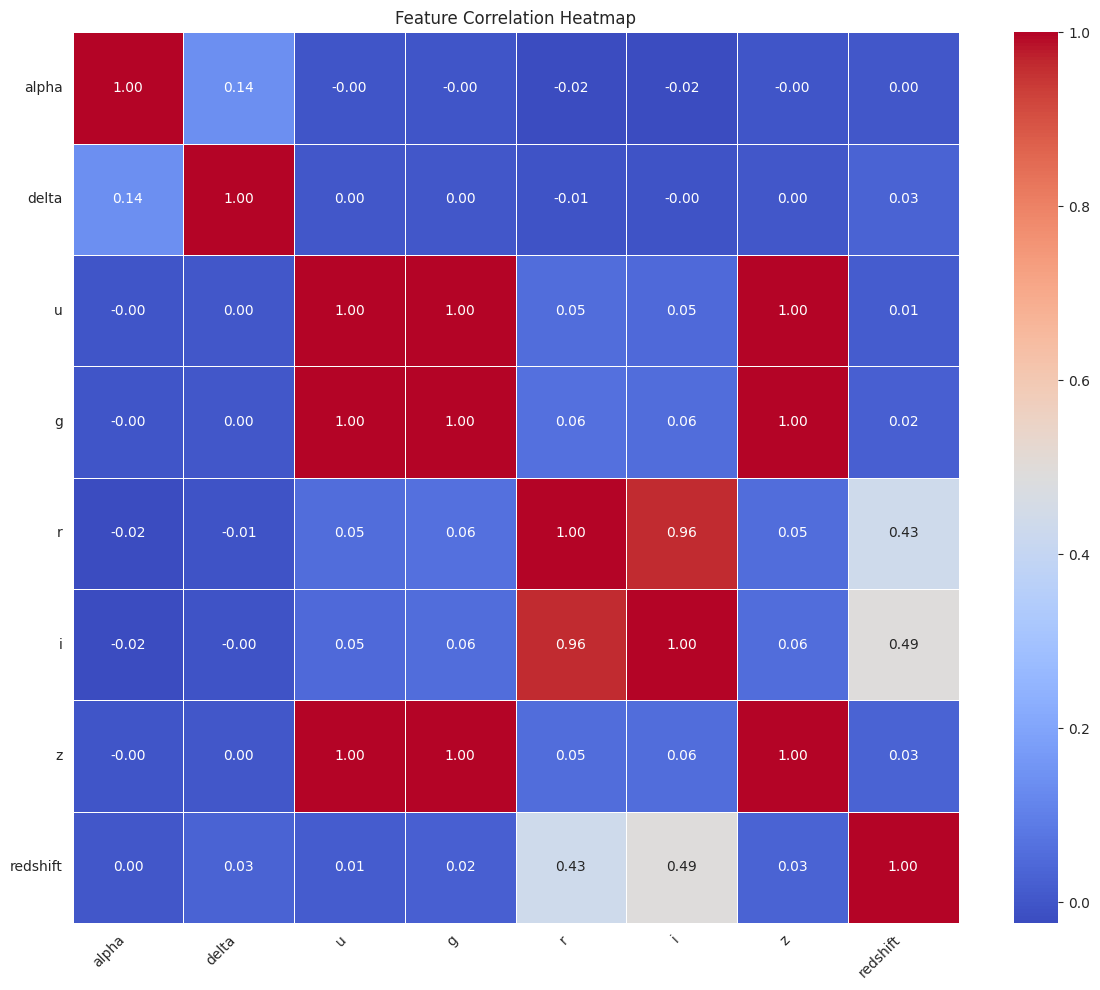


Top 5 highly correlated feature pairs:
u - g: 1.00
g - z: 1.00
z - u: 1.00
r - i: 0.96
redshift - i: 0.49


In [40]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.set_style("white")
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_plot_2.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 highly correlated feature pairs:')
correlation_pairs = correlation_matrix.unstack()
sorted_pairs = correlation_pairs.sort_values(kind="quicksort", ascending=False)

positive_corr_pairs = sorted_pairs[sorted_pairs != 1]

count = 0
seen_pairs = set()
for (idx1, idx2), value in positive_corr_pairs.items():
    if idx1 != idx2 and frozenset([idx1, idx2]) not in seen_pairs:
        print(f"{idx1} - {idx2}: {value:.2f}")
        seen_pairs.add(frozenset([idx1, idx2]))
        count += 1
        if count >= 5:
            break

## Distributions by Class

These plots show how each feature is distributed for each class. If the bumps are really separated, it means that feature is probably a good predictor.

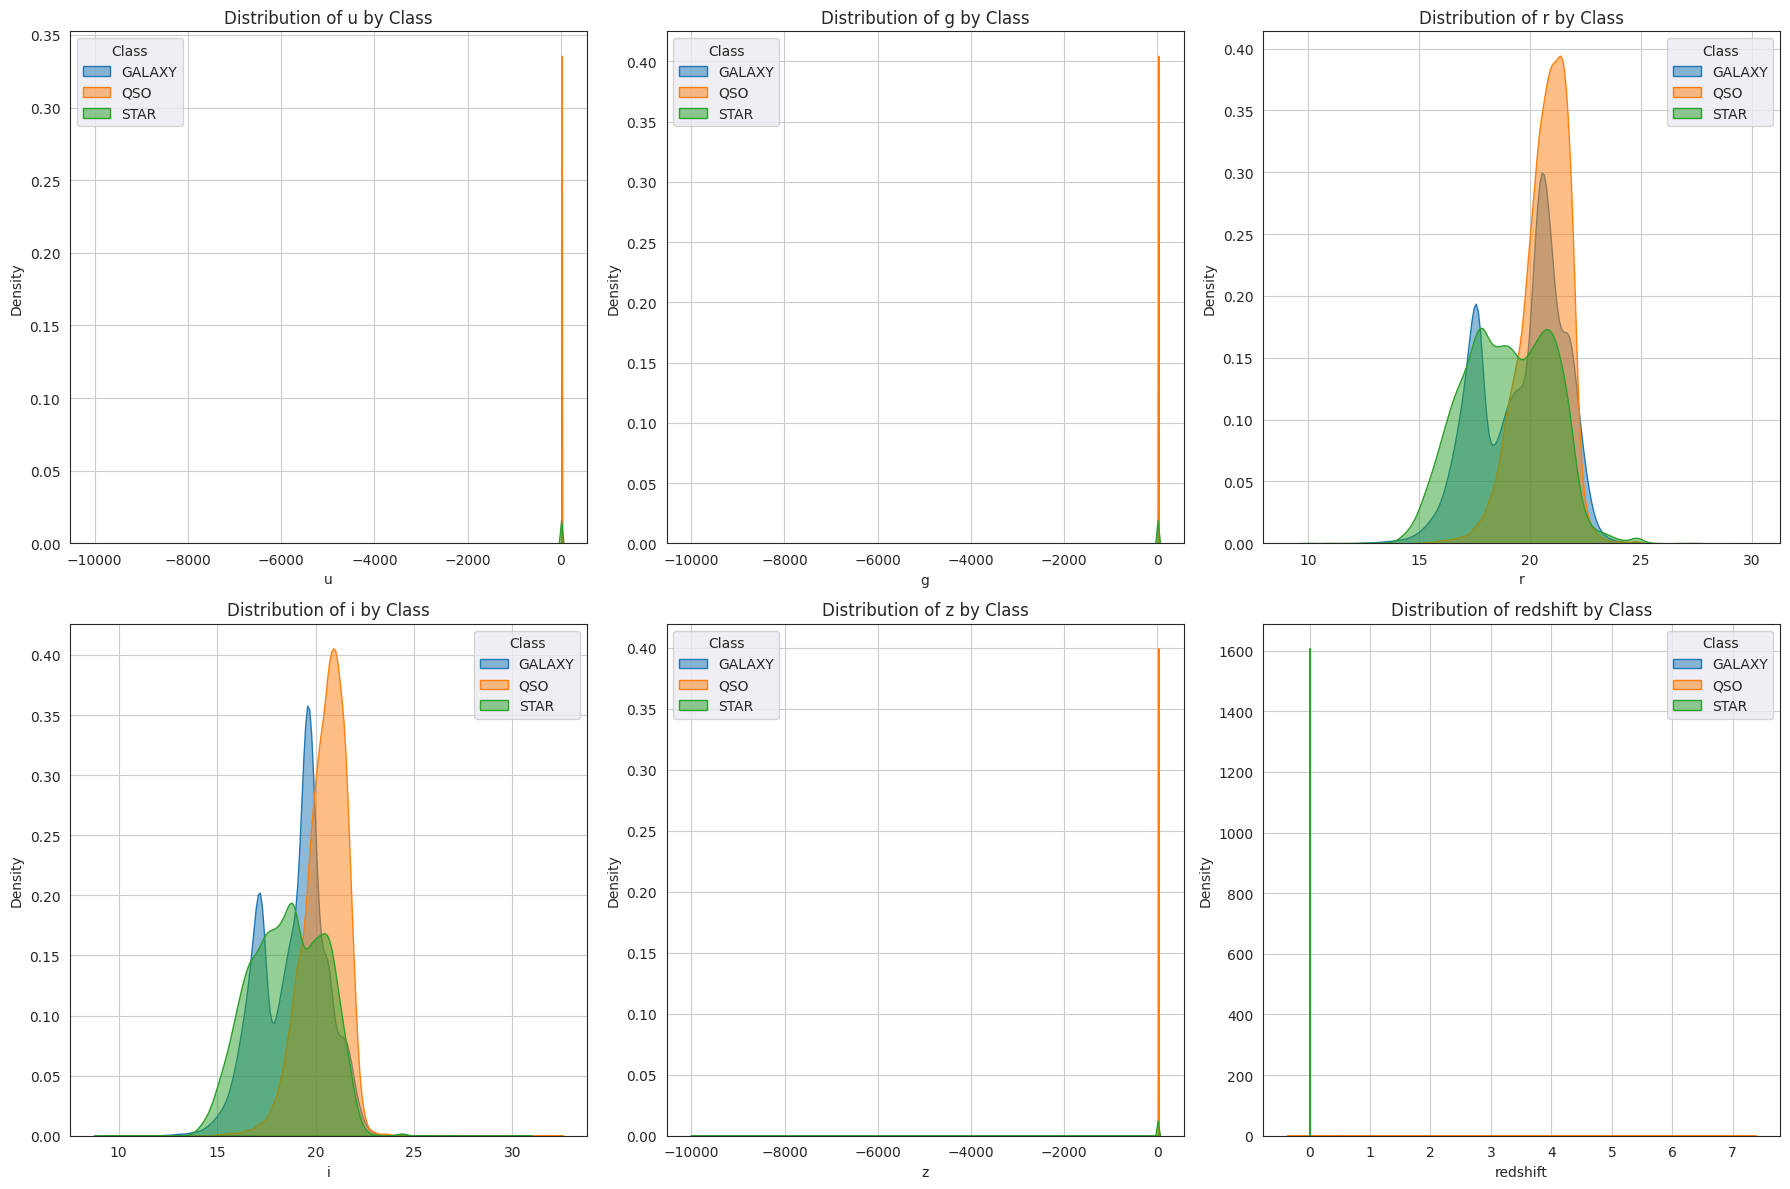

In [41]:
features_for_kde = ['u', 'g', 'r', 'i', 'z', 'redshift']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
sns.set_style("darkgrid")
axes = axes.flatten()

for i, feature in enumerate(features_for_kde):
    for class_type in df['class'].unique():
        sns.kdeplot(x=feature, data=df[df['class'] == class_type],
                    ax=axes[i], label=class_type, fill=True, alpha=0.5)
    axes[i].set_title(f'Distribution of {feature} by Class')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend(title='Class')
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('eda_plot_3.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing & PCA

In [42]:
X = df.drop('class', axis=1)
y = df['class']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Original classes: {label_encoder.classes_}")
print(f"Encoded labels: {np.unique(y_encoded)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Original classes: ['GALAXY' 'QSO' 'STAR']
Encoded labels: [0 1 2]


### 2D PCA Plot

This 2D plot helps visualize if our different classes are separating well with just two principal components. We're seeing how much variance each component explains.

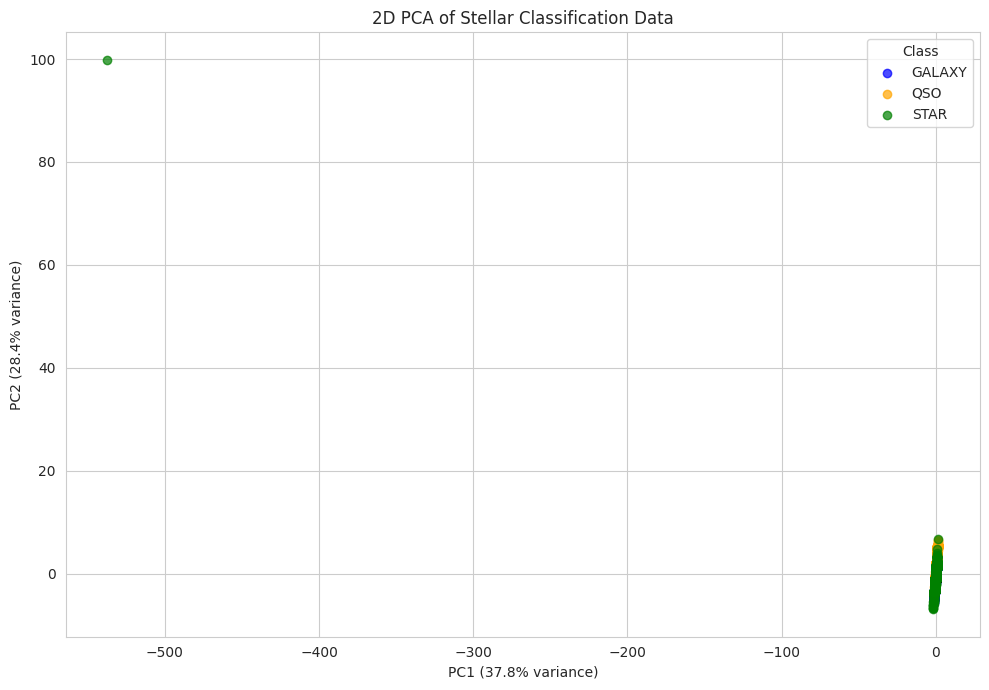

In [43]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

class_colors = {'GALAXY': 'blue', 'QSO': 'orange', 'STAR': 'green'}

encoded_to_class = {i: class_name for i, class_name in enumerate(label_encoder.classes_)}

colors = [class_colors[encoded_to_class[label]] for label in y_encoded]

for i, class_name in enumerate(label_encoder.classes_):
    idx = y_encoded == i
    plt.scatter(X_pca_2d[idx, 0], X_pca_2d[idx, 1],
                color=class_colors[class_name], label=class_name, alpha=0.7)

explained_variance_ratio_2d = pca_2d.explained_variance_ratio_ * 100
plt.xlabel(f'PC1 ({explained_variance_ratio_2d[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_variance_ratio_2d[1]:.1f}% variance)')
plt.title('2D PCA of Stellar Classification Data')
plt.legend(title='Class')
plt.grid(True)
plt.tight_layout()
plt.savefig('eda_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

### 3D PCA Plot

Adding a third principal component gives us another view. Sometimes, clusters that look mixed in 2D separate out better here.

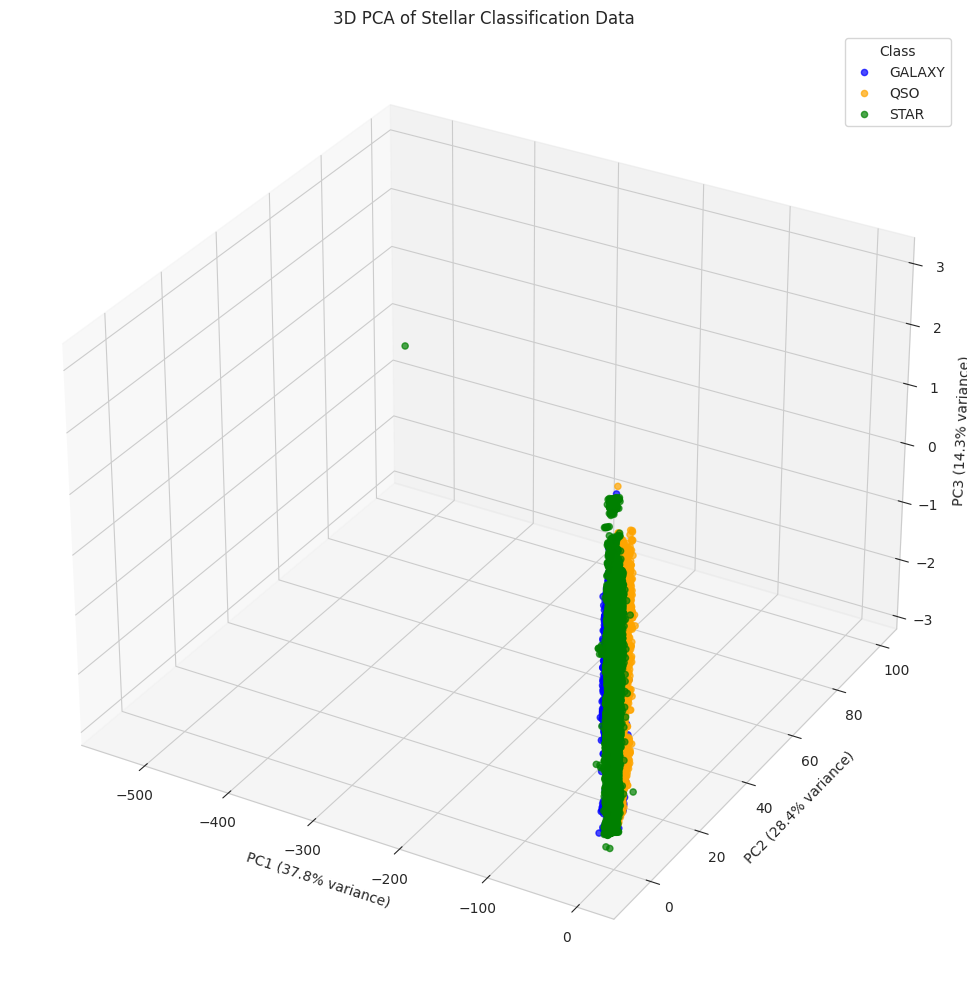

In [44]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
sns.set_style("whitegrid")

for i, class_name in enumerate(label_encoder.classes_):
    idx = y_encoded == i
    ax.scatter(X_pca_3d[idx, 0], X_pca_3d[idx, 1], X_pca_3d[idx, 2],
               color=class_colors[class_name], label=class_name, alpha=0.7)

explained_variance_ratio_3d = pca_3d.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({explained_variance_ratio_3d[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_variance_ratio_3d[1]:.1f}% variance)')
ax.set_zlabel(f'PC3 ({explained_variance_ratio_3d[2]:.1f}% variance)')
ax.set_title('3D PCA of Stellar Classification Data')
ax.legend(title='Class')
plt.tight_layout()
plt.savefig('eda_pca_3d.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Training

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (80000, 8)
X_test shape: (20000, 8)
y_train shape: (80000,)
y_test shape: (20000,)


In [46]:
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

In [47]:
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Random Forest Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



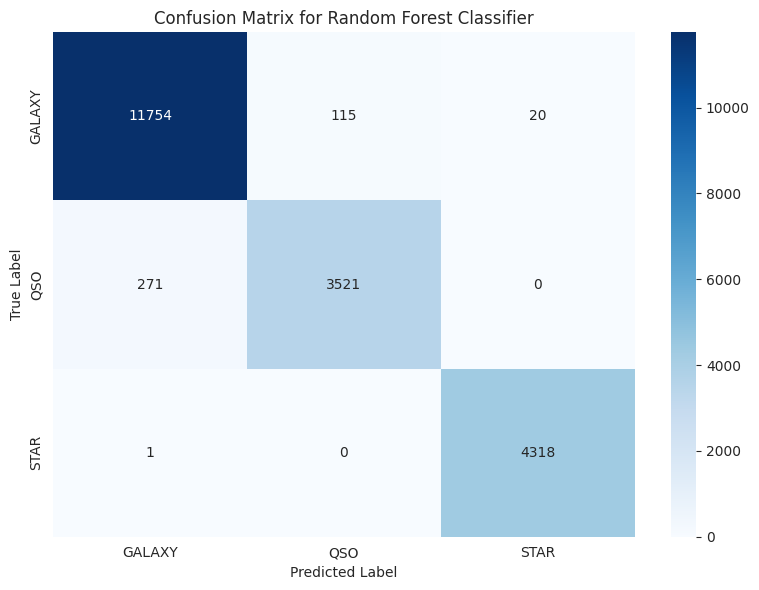

In [48]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.set_style("white")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# This confusion matrix helps see where the model gets confused.
# High numbers off the diagonal mean it's misclassifying those classes a lot.

In [49]:
accuracy = rf_classifier.score(X_test, y_test)
print(f"Overall Accuracy: {accuracy:.4f}")

# Accuracy is good, but with imbalanced data, I also care about precision, recall, and F1-score.

Overall Accuracy: 0.9797


## Fixed Params Model Comparison

In [50]:
print("Training RandomForestClassifier...")
fixed_rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
fixed_rf_classifier.fit(X_train, y_train)
print("RandomForestClassifier training finished.")

y_pred_fixed_rf = fixed_rf_classifier.predict(X_test)
accuracy_fixed_rf = fixed_rf_classifier.score(X_test, y_test)

print("\nRandomForestClassifier Report (Fixed Params):")
print(classification_report(y_test, y_pred_fixed_rf, target_names=label_encoder.classes_))
print(f"RF Accuracy: {accuracy_fixed_rf:.4f}")

Training RandomForestClassifier...
RandomForestClassifier training finished.

RandomForestClassifier Report (Fixed Params):
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000

RF Accuracy: 0.9794


In [51]:
print("\nTraining XGBClassifier...")
fixed_xgb_classifier = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    use_label_encoder=False, # to avoid a warning
    random_state=42,
    n_jobs=-1
)
fixed_xgb_classifier.fit(X_train, y_train)
print("XGBClassifier training finished.")

y_pred_fixed_xgb = fixed_xgb_classifier.predict(X_test)
accuracy_fixed_xgb = fixed_xgb_classifier.score(X_test, y_test)

print("\nXGBClassifier Report (Fixed Params):")
print(classification_report(y_test, y_pred_fixed_xgb, target_names=label_encoder.classes_))
print(f"XGB Accuracy: {accuracy_fixed_xgb:.4f}")


Training XGBClassifier...
XGBClassifier training finished.

XGBClassifier Report (Fixed Params):
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO       0.96      0.93      0.95      3792
        STAR       0.99      0.99      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000

XGB Accuracy: 0.9755


Comparing accuracies...
RandomForest (Accuracy: 0.9794) performed better or equally well.


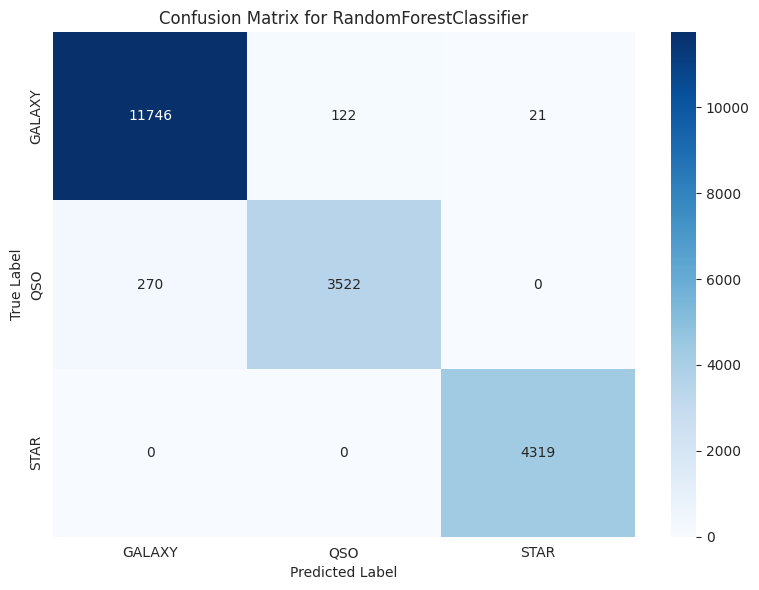

In [52]:
print("Comparing accuracies...")
if accuracy_fixed_rf >= accuracy_fixed_xgb:
    print(f"RandomForest (Accuracy: {accuracy_fixed_rf:.4f}) performed better or equally well.")
    better_model_name = "RandomForestClassifier"
    cm_better_model = confusion_matrix(y_test, y_pred_fixed_rf)
else:
    print(f"XGB (Accuracy: {accuracy_fixed_xgb:.4f}) performed better.")
    better_model_name = "XGBClassifier"
    cm_better_model = confusion_matrix(y_test, y_pred_fixed_xgb)

plt.figure(figsize=(8, 6))
sns.set_style("white")
sns.heatmap(cm_better_model, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix for {better_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f'{better_model_name.lower().replace(" ", "_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC Curves

Now to check out the ROC curves. This tells us how good our Random Forest model is at distinguishing between the different classes across all possible thresholds. Higher AUC is better.

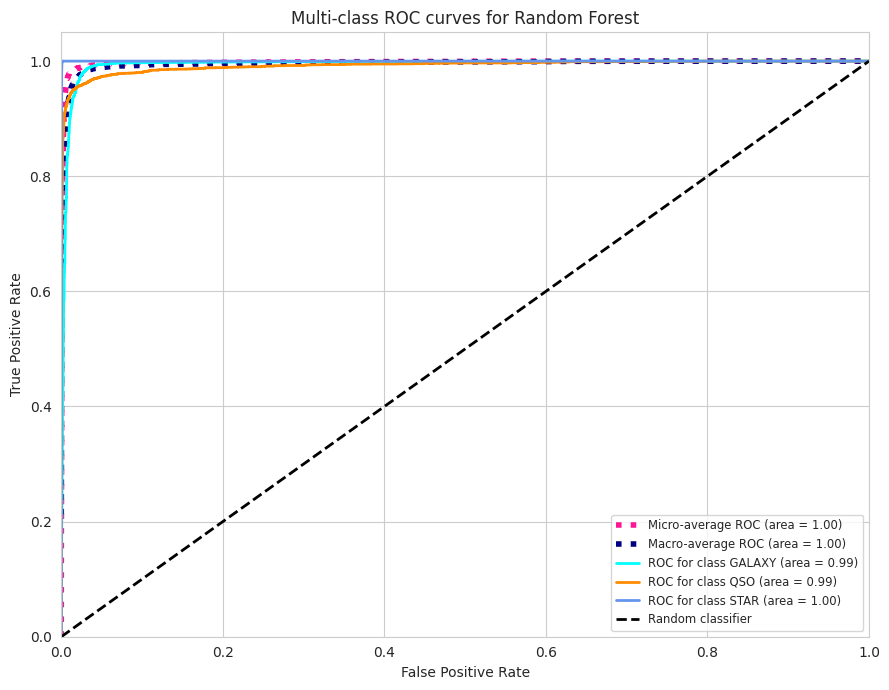


AUC scores per class:
  GALAXY: 0.9946
  QSO: 0.9922
  STAR: 0.9999
  Micro-average AUC: 0.9974
  Macro-average AUC: 0.9956


In [53]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

best_rf = fixed_rf_classifier # using the fixed param RF as the best one here

n_classes = len(label_encoder.classes_)

y_score_rf = best_rf.predict_proba(X_test)

y_test_binarized = label_binarize(y_test, classes=np.arange(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score_rf[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_score_rf.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(9, 7))
sns.set_style("whitegrid")

plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC (area = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC (area = {roc_auc["macro"]:.2f})',
         color='navy', linestyle=':', linewidth=4)

colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC for class {class_name} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC curves for Random Forest')
plt.legend(loc="lower right", fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.savefig('rf_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAUC scores per class:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name}: {roc_auc[i]:.4f}")
print(f"  Micro-average AUC: {roc_auc['micro']:.4f}")
print(f"  Macro-average AUC: {roc_auc['macro']:.4f}")

## Feature Importance

In [54]:
feature_importances = fixed_rf_classifier.feature_importances_

feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

display(feature_importance_df.head(10))

,Feature,Importance
0,redshift,0.632615
1,z,0.084444
2,i,0.072505
3,u,0.068938
4,g,0.067928
5,r,0.047492
6,alpha,0.013426
7,delta,0.012652


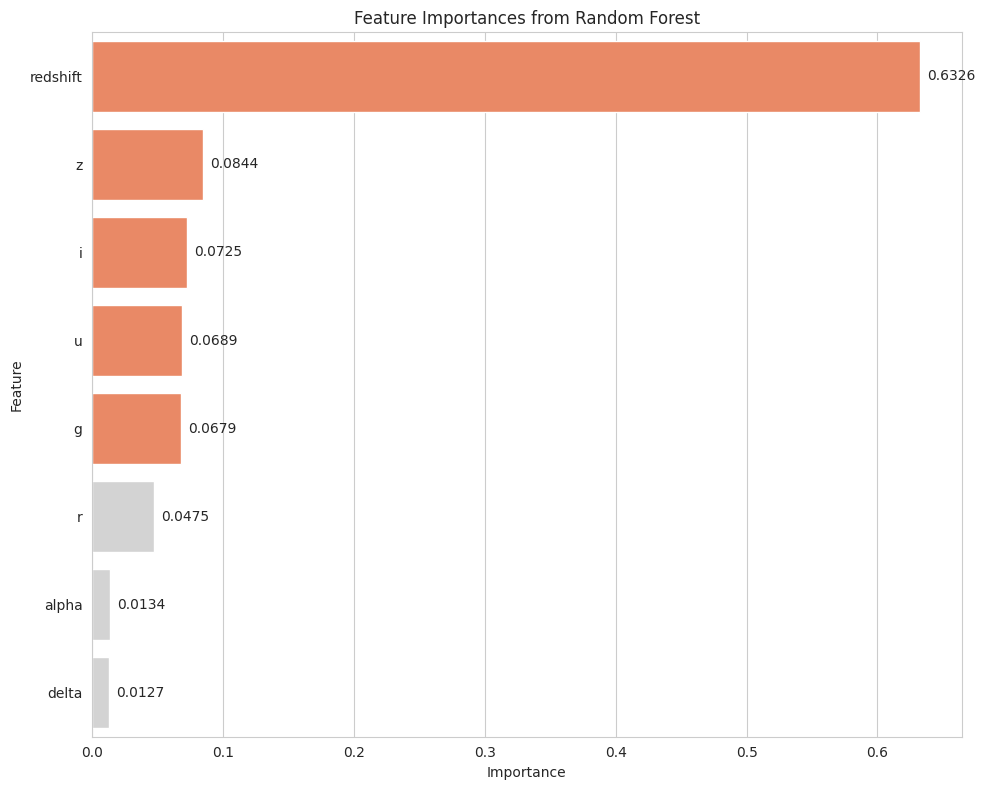

In [55]:
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

top_5_color = 'coral'
other_color = 'lightgrey'

colors = [top_5_color if i < 5 else other_color for i in range(len(feature_importance_df))]

ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette=colors,
    legend=False
)

plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5)

plt.tight_layout()
plt.savefig('rf_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
print("Top 5 Important Features:")
display(feature_importance_df.head(5).round(4))

Top 5 Important Features:


,Feature,Importance
0,redshift,0.6326
1,z,0.0844
2,i,0.0725
3,u,0.0689
4,g,0.0679


### Why these features matter

*   **redshift:** This is huge in astronomy! It tells us how much an object's light is stretched because the universe is expanding. High redshift usually means really distant galaxies or quasars. Lower values are more for closer stars. It's super helpful for telling stars, galaxies, and quasars apart.

*   **z (z-band magnitude):** This is the object's brightness in the near-infrared. Different types of stars and galaxies glow differently at various wavelengths, so checking the z-band, especially with other bands, helps characterize them.

*   **i (i-band magnitude):** Another brightness measurement, this time also in the near-infrared. It's another piece of the puzzle for an object's 'light signature,' which is key to classifying it.

*   **u (u-band magnitude):** This measures brightness in ultraviolet light. Hot, young stars and active galaxies (like quasars) are often brighter in UV. Older stars or regular galaxies are usually fainter here, which makes it good for sorting them.

*   **g (g-band magnitude):** This is brightness in green light. Combined with the other bands (u, r, i), the g-band helps build a 'photometric fingerprint' of the object. Using these magnitudes together, like in color indices (e.g., u-g), is often more powerful than just one band because it really shows off the object's unique spectral shape.